# 0. Overview
- Task: classification
- dataset: MNIST
- Model: Multi layer perceptron
- lossfunction: Cross entropy
- Optimizer: SGD

In [1]:
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import random_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Data Collection & Preprocessing

In [2]:
# To tensor & normalization
mnist_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean = (0.5, ), std = (1, ))])

train_data = datasets.MNIST(root='./', train=True, download=True, transform=mnist_transform)
test_data = datasets.MNIST(root='./', train=False, download=True, transform=mnist_transform)

# split the data
train_data, valid_data = random_split(dataset=train_data, lengths=[54000, 6000])

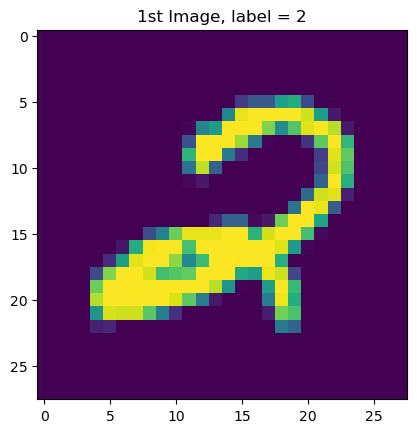

In [3]:
# Visualization
train_0_x, train_0_y = train_data[0]
plt.figure()
plt.imshow(train_0_x.squeeze())
plt.title(f'1st Image, label = {train_0_y}')
plt.show()

In [4]:
print(f'Training data: {len(train_data)}')
print(f'Validation data: {len(valid_data)}')
print(f'Test data: {len(test_data)}')

Training data: 54000
Validation data: 6000
Test data: 10000


In [7]:
batch_size = 32
learning_rate = 1e-2

In [ ]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_data, batch_size=len(valid_data))
test_loader = DataLoader(test_data, batch_size=len(test_data))

# 2. Modeling

In [10]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        layers = [300, 100]
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features, layers[0])
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(layers[0], layers[1])
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(layers[1], out_features)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        y = self.fc3(x)
        return y

# 3. Training

In [ ]:
import torch.optim as optim
import numpy as np
class Trainer:
    def __init__(self, model, train_loader, valid_loader, lr, max_epoch):
        self.model = model
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.max_epoch = max_epoch

        self.optimizer = optim.SGD(self.model.parameters(), lr=lr)
        # CrossEntropyLoss() function contains softmax inside
        # That's why you dont need to specify the softmax function
        # separately
        self.loss_fn = nn.CrossEntropyLoss()

        self.n_epoch = 0

    def epoch(self, dataloader):
        iter_loss, iter_acc = [], []
        last_grad_performed = False
        for data ,label in dataloader:
            # why not model.forward(data): because of Module class,
            # the forward method you implemented is automatically executed
            # in a safer and more robust way
            y_pred = self.model(data) 
            _, idx = torch.max(y_pred, dim=1)
            loss = self.loss_fn(y_pred, label)
            iter_loss.append(loss.item())
            if y_pred.requires_grad:
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                last_grad_performed = True
            acc_partial = (idx == label).sum().float()
            acc_partial = acc_partial / len(label)
            iter_acc.append(acc_partial.item())

        if last_grad_performed:
            self.n_epoch += 1

        return np.average(iter_loss), np.average(iter_acc)
    
    def train(self):
        while self.n_epoch < self.max_epoch:
            self.model.train()
            self.epoch(self.train_loader)
            self.model.eval()
            with torch.no_grad():
                self.epoch(self.valid_loader)

In [25]:
max_epoch = 10
trainer = Trainer(MLP(784, 10), train_loader, valid_loader, learning_rate, max_epoch)
trainer.train()

In [ ]:
# Model Saving
torch.save(trainer.model.state_dict(), './model.pth')

In [ ]:
# 저장한 모델을 언제든 사용할 수 있도록 로딩
# model = MLP(in_features = 784, out_features = 10) # .to(device)
# model.load_state_dict(torch.load('./model.pth'))

# 4. Evaluation

In [27]:
# Acc
with torch.no_grad():
    loss, acc = trainer.epoch(test_loader)
print(f'acc: {acc:.3f}')
print(f'loss: {loss:.3f}')


acc: 0.951
loss: 0.162
